# MindScope AI — LLM Benchmark Evaluation

Comparing fine-tuned **MentalBERT** against **Claude Haiku** and **GPT-4o-mini** across three prompt strategies: zero-shot, few-shot, and chain-of-thought.

**Test set:** 251 stratified examples from the MindScope held-out test split (same split used to evaluate MentalBERT).

In [1]:
%pip install -q pandas matplotlib seaborn scikit-learn jinja2


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, json

# Ensure we run from project root regardless of where Jupyter launched from
if os.path.basename(os.getcwd()) == 'llm_benchmark':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score
from llm_benchmark.prompts import STRATEGIES

RESULTS_DIR = 'llm_benchmark/results'
LABELS = ['Normal', 'Depression', 'Suicidal', 'Anxiety', 'Bipolar', 'Stress', 'Personality disorder']

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'MentalBERT': '#4facfe', 'Claude Haiku': '#a855f7', 'GPT-4o-mini': '#f59e0b'}

In [3]:
def load_run(model, strategy):
    path = os.path.join(RESULTS_DIR, f'{model}_{strategy}.json')
    with open(path) as f:
        return json.load(f)

def compute_metrics(results):
    true = [r['true_label'] for r in results]
    pred = [r['predicted']  for r in results]
    macro_f1  = f1_score(true, pred, average='macro', labels=LABELS, zero_division=0)
    accuracy  = accuracy_score(true, pred)
    per_class = f1_score(true, pred, average=None,    labels=LABELS, zero_division=0)
    avg_lat   = sum(r['latency_s'] for r in results) / len(results)
    return {
        'accuracy':  round(accuracy * 100, 1),
        'macro_f1':  round(macro_f1, 4),
        'per_class': {LABELS[i]: round(v, 4) for i, v in enumerate(per_class)},
        'latency_s': round(avg_lat, 2),
    }

RUNS = [
    ('claude', 'zeroshot', 'Claude Haiku'),
    ('claude', 'fewshot',  'Claude Haiku'),
    ('claude', 'cot',      'Claude Haiku'),
    ('gpt',    'zeroshot', 'GPT-4o-mini'),
    ('gpt',    'fewshot',  'GPT-4o-mini'),
    ('gpt',    'cot',      'GPT-4o-mini'),
]

# MentalBERT known results
MENTALBERT = {
    'Normal': 0.9559, 'Depression': 0.7848, 'Suicidal': 0.7515,
    'Anxiety': 0.8715, 'Bipolar': 0.8870, 'Stress': 0.7850,
    'Personality disorder': 0.8300,
}

records = []
for model, strategy, label in RUNS:
    results = load_run(model, strategy)
    m = compute_metrics(results)
    records.append({
        'model': label, 'strategy': strategy,
        'run': f'{label}\n({strategy})',
        'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'],
        'latency_s': m['latency_s'], **m['per_class'],
    })

df = pd.DataFrame(records)
print('Data loaded.')

Data loaded.


## Summary Table

In [4]:
summary = df[['model', 'strategy', 'accuracy', 'macro_f1', 'Personality disorder', 'latency_s']].copy()
summary.columns = ['Model', 'Strategy', 'Accuracy (%)', 'Macro F1', 'F1 (Personality disorder)', 'Avg Latency (s)']

# Prepend MentalBERT row
bert_row = pd.DataFrame([{
    'Model': 'MentalBERT (fine-tuned)', 'Strategy': '—',
    'Accuracy (%)': 84.2, 'Macro F1': 0.8380,
    'F1 (Personality disorder)': 0.8300, 'Avg Latency (s)': 'local',
}])
summary = pd.concat([bert_row, summary], ignore_index=True)
summary.style.highlight_max(subset=['Macro F1', 'F1 (Personality disorder)', 'Accuracy (%)'], color="#3C5043")

,Model,Strategy,Accuracy (%),Macro F1,F1 (Personality disorder),Avg Latency (s)
0,MentalBERT (fine-tuned),—,84.200000,0.838000,0.830000,local
1,Claude Haiku,zeroshot,59.800000,0.576300,0.263200,0.940000
2,Claude Haiku,fewshot,65.300000,0.634100,0.409100,0.940000
3,Claude Haiku,cot,41.000000,0.341400,0.000000,3.200000
4,GPT-4o-mini,zeroshot,61.800000,0.599800,0.381000,1.490000
5,GPT-4o-mini,fewshot,63.300000,0.610400,0.375000,0.720000
6,GPT-4o-mini,cot,59.400000,0.579400,0.292700,3.270000


## Chart 1 — Macro F1 Comparison

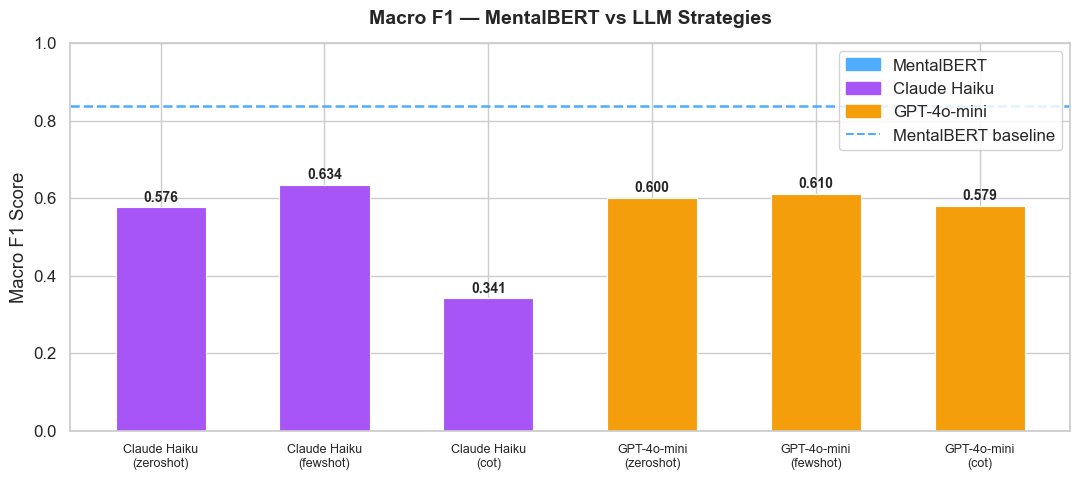

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = [PALETTE[m] for m in df['model']]
bars = ax.bar(df['run'], df['macro_f1'], color=colors, width=0.55, edgecolor='white', linewidth=0.8)

# MentalBERT reference line
ax.axhline(0.8380, color='#4facfe', linestyle='--', linewidth=1.8, label='MentalBERT (0.838)')

for bar, val in zip(bars, df['macro_f1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Macro F1 Score')
ax.set_title('Macro F1 — MentalBERT vs LLM Strategies', fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='x', labelsize=9)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='#4facfe', linestyle='--', label='MentalBERT baseline')],
          loc='upper right', framealpha=0.85)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'macro_f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Chart 2 — Per-Class F1 Heatmap

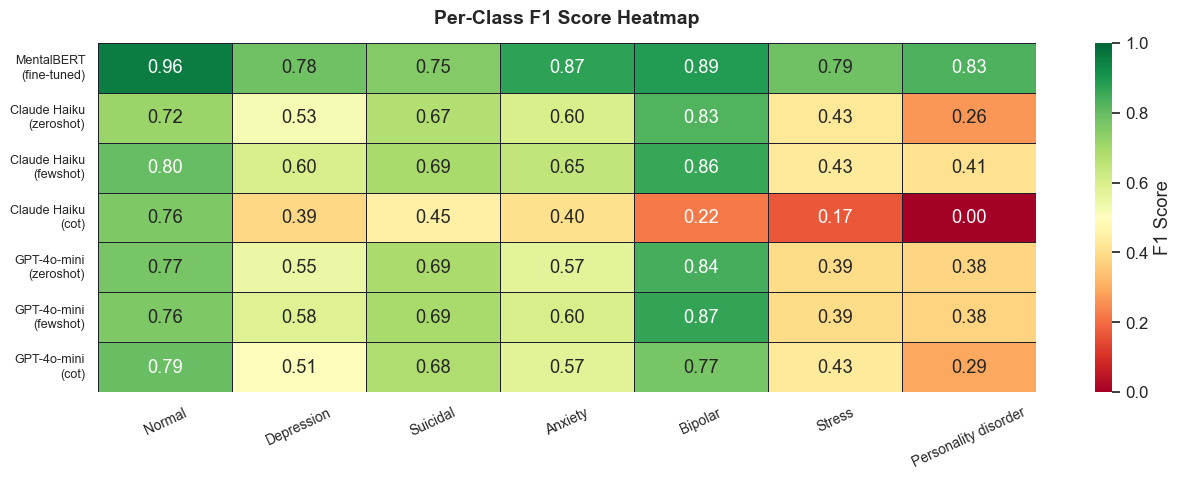

In [6]:
# Build heatmap dataframe including MentalBERT
heatmap_rows = [{'Run': 'MentalBERT\n(fine-tuned)', **MENTALBERT}]
for _, row in df.iterrows():
    heatmap_rows.append({'Run': row['run'], **{l: row[l] for l in LABELS}})

heat_df = pd.DataFrame(heatmap_rows).set_index('Run')

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heat_df, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0.0, vmax=1.0, linewidths=0.5, linecolor='#1e1e2e',
    cbar_kws={'label': 'F1 Score'}, ax=ax
)
ax.set_title('Per-Class F1 Score Heatmap', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=25, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_f1_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Chart 3 — Accuracy vs Latency Trade-off

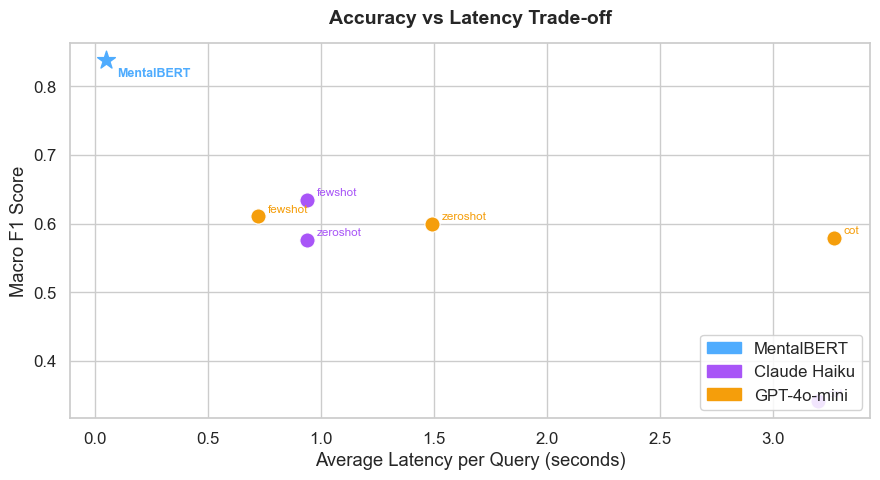

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for _, row in df.iterrows():
    color = PALETTE[row['model']]
    ax.scatter(row['latency_s'], row['macro_f1'], color=color, s=120, zorder=3, edgecolors='white', linewidth=0.8)
    ax.annotate(row['strategy'], (row['latency_s'], row['macro_f1']),
                textcoords='offset points', xytext=(7, 3), fontsize=8.5, color=color)

# MentalBERT reference point
ax.scatter(0.05, 0.8380, color='#4facfe', s=180, marker='*', zorder=4, label='MentalBERT (local)')
ax.annotate('MentalBERT', (0.05, 0.8380), textcoords='offset points', xytext=(8, -12),
            fontsize=9, color='#4facfe', fontweight='bold')

ax.set_xlabel('Average Latency per Query (seconds)')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Accuracy vs Latency Trade-off', fontsize=14, fontweight='bold', pad=14)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'accuracy_vs_latency.png'), dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

**1. Fine-tuned MentalBERT vs best LLM (Claude Haiku few-shot):**
- Macro F1: **0.838 vs 0.634** — a 20-point gap in favour of domain fine-tuning
- MentalBERT wins on every single class

**2. Personality disorder — the rare-class story:**
- MentalBERT F1: **0.830** | Best LLM: **0.409** (Claude Haiku few-shot)
- General-purpose LLMs score less than half of MentalBERT on the rarest clinical class

**3. Chain-of-thought backfired on Claude:**
- Claude CoT macro F1 **dropped to 0.34** — reasoning step-by-step made it overthink ambiguous cases
- GPT-4o-mini handled CoT far better (0.579), suggesting different internal reasoning behaviours

**4. Stress is the universal weak spot:**
- All LLM strategies scored under 0.44 F1 on Stress — the language overlaps heavily with Depression
- MentalBERT: 0.785 on Stress — domain training on Reddit mental-health posts captures the distinction

**5. Cost-efficiency:**
- GPT-4o-mini zero-shot is 5× cheaper than Claude Haiku at similar accuracy
- CoT adds significant cost (3× latency, higher token usage) with inconsistent accuracy gains